In [1]:
# =============================================================
# NB05 — OPTIMISATION DES HYPERPARAMÈTRES (OPTUNA)
# =============================================================
# SECTION 0 — IMPORTS ET CONFIGURATION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
from pathlib import Path

import warnings
import optuna

warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

from optuna.samplers import TPESampler
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    average_precision_score, roc_auc_score, recall_score,
    precision_score, fbeta_score, brier_score_loss, make_scorer,
)

# Seed (reproductibilité totale)
SEED = 42
np.random.seed(SEED)

# Réduire le bruit des logs Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.precision", 4)

# Dossiers
DATA_PROC = Path("../data/processed")
MODELS    = Path("../models")
REPORTS   = Path("../reports")
FIGURES   = Path("../figures")
for d in [MODELS, REPORTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Environnement configuré.")
print(f"  Optuna version : {optuna.__version__}")

✓ Environnement configuré.
  Optuna version : 4.9.0


In [2]:
# =============================================================
# SECTION 1 — CHARGEMENT DES DONNÉES
# =============================================================

# Train : sert à la CV pour l'optimisation
# Val   : sert à VÉRIFIER que l'optimisation ne sur-ajuste pas
# Test  : reste fermé (NB06)
X_train = pd.read_pickle(DATA_PROC / "X_train.pkl")
y_train = pd.read_pickle(DATA_PROC / "y_train.pkl")
X_val   = pd.read_pickle(DATA_PROC / "X_val.pkl")
y_val   = pd.read_pickle(DATA_PROC / "y_val.pkl")

print("=" * 55)
print("DONNÉES CHARGÉES")
print("=" * 55)
print(f"  X_train : {X_train.shape} | positifs {y_train.mean()*100:.2f}%")
print(f"  X_val   : {X_val.shape} | positifs {y_val.mean()*100:.2f}%")

# Ratio de déséquilibre (base pour la plage de scale_pos_weight)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n  Ratio négatifs/positifs (train) : {ratio:.2f}")
print("  ⚠️  Test set NON chargé (réservé au NB06).")

DONNÉES CHARGÉES
  X_train : (48990, 186) | positifs 8.98%
  X_val   : (10498, 186) | positifs 8.98%

  Ratio négatifs/positifs (train) : 10.14
  ⚠️  Test set NON chargé (réservé au NB06).


In [3]:
# =============================================================
# SECTION 2 — RAPPEL DU MODÈLE CHAMPION
# =============================================================

# On lit le champion sélectionné au NB04
with open(REPORTS / "best_model_name.txt") as f:
    champion = f.read().strip()

print(f"Modèle champion (NB04) : {champion}")
print(f"→ On optimise UNIQUEMENT ce modèle : LightGBM")

# Score baseline du champion (depuis le tableau NB04) pour comparaison finale
baseline_scores = pd.read_csv(REPORTS / "baseline_comparison.csv", index_col=0)
pr_auc_baseline = baseline_scores.loc["LightGBM", "PR-AUC"]
print(f"\nPR-AUC baseline LightGBM (val, NB04) : {pr_auc_baseline:.4f}")
print("→ objectif : faire mieux grâce à l'optimisation.")

Modèle champion (NB04) : LightGBM
→ On optimise UNIQUEMENT ce modèle : LightGBM

PR-AUC baseline LightGBM (val, NB04) : 0.1766
→ objectif : faire mieux grâce à l'optimisation.


In [4]:
# =============================================================
# SECTION 3 — FONCTION OBJECTIVE
# =============================================================

# Optuna appelle cette fonction à chaque essai. Elle :
#  1. propose des hyperparamètres dans des plages définies
#  2. évalue LightGBM en CV 5-fold stratifiée sur le train
#  3. renvoie la PR-AUC moyenne (qu'Optuna va MAXIMISER)

# CV stratifiée réutilisée (même découpage à chaque essai → comparaison juste)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scorer PR-AUC (necessite les probabilités)
pr_auc_scorer = make_scorer(average_precision_score, response_method="predict_proba")


def objective(trial):
    # --- Espace de recherche des hyperparamètres ---
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800, step=100),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 127),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 100),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        # AMÉLIORATION 1 : on optimise la pondération du déséquilibre
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", ratio*0.5, ratio*1.5),
    }

    model = LGBMClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    # CV 5-fold, métrique PR-AUC
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring=pr_auc_scorer, n_jobs=-1)
    return scores.mean()

print("✓ Fonction objective définie.")
print("  Optimise : PR-AUC (CV 5-fold stratifiée)")
print("  10 hyperparamètres, dont scale_pos_weight (déséquilibre)")

✓ Fonction objective définie.
  Optimise : PR-AUC (CV 5-fold stratifiée)
  10 hyperparamètres, dont scale_pos_weight (déséquilibre)


In [5]:
# =============================================================
# SECTION 4 — LANCEMENT DE L'OPTIMISATION
# =============================================================

N_TRIALS = 150   # 150-200 recommandé

# AMÉLIORATION 3 : sampler seedé → optimisation reproductible
# Pruner : arrête tôt les essais peu prometteurs
sampler = TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner()

study = optuna.create_study(
    direction="maximize",       # on maximise la PR-AUC
    sampler=sampler,
    pruner=pruner,
    study_name="lgbm_optimization",
)

print(f"Lancement de l'optimisation : {N_TRIALS} essais...")
print("(cela peut prendre 20-30 minutes)\n")

start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
duree = time.time() - start

print(f"\n✓ Optimisation terminée en {duree/60:.1f} min")
print(f"  Meilleure PR-AUC (CV) : {study.best_value:.4f}")

Lancement de l'optimisation : 150 essais...
(cela peut prendre 20-30 minutes)



  0%|          | 0/150 [00:00<?, ?it/s]


✓ Optimisation terminée en 12.7 min
  Meilleure PR-AUC (CV) : 0.1795


In [6]:
# =============================================================
# SECTION 5 — RÉSULTATS DE L'OPTIMISATION
# =============================================================

print("=" * 55)
print("MEILLEURS HYPERPARAMÈTRES")
print("=" * 55)
for k, v in study.best_params.items():
    print(f"  {k:<18} : {v}")

print(f"\n  PR-AUC moyenne (CV 5-fold) : {study.best_value:.4f}")
print(f"  Essais complétés : {len(study.trials)}")

# Comparaison avec le baseline
gain = study.best_value - pr_auc_baseline
print(f"\n  PR-AUC baseline (NB04) : {pr_auc_baseline:.4f}")
print(f"  Gain par optimisation  : {gain:+.4f}")

MEILLEURS HYPERPARAMÈTRES
  n_estimators       : 500
  learning_rate      : 0.026721494147148115
  num_leaves         : 89
  max_depth          : 5
  min_child_samples  : 43
  subsample          : 0.9239867434238693
  colsample_bytree   : 0.6983809577571662
  reg_alpha          : 0.006642744990886591
  reg_lambda         : 0.5667534209221221
  scale_pos_weight   : 6.933963889524102

  PR-AUC moyenne (CV 5-fold) : 0.1795
  Essais complétés : 150

  PR-AUC baseline (NB04) : 0.1766
  Gain par optimisation  : +0.0028


<Figure size 1100x500 with 0 Axes>

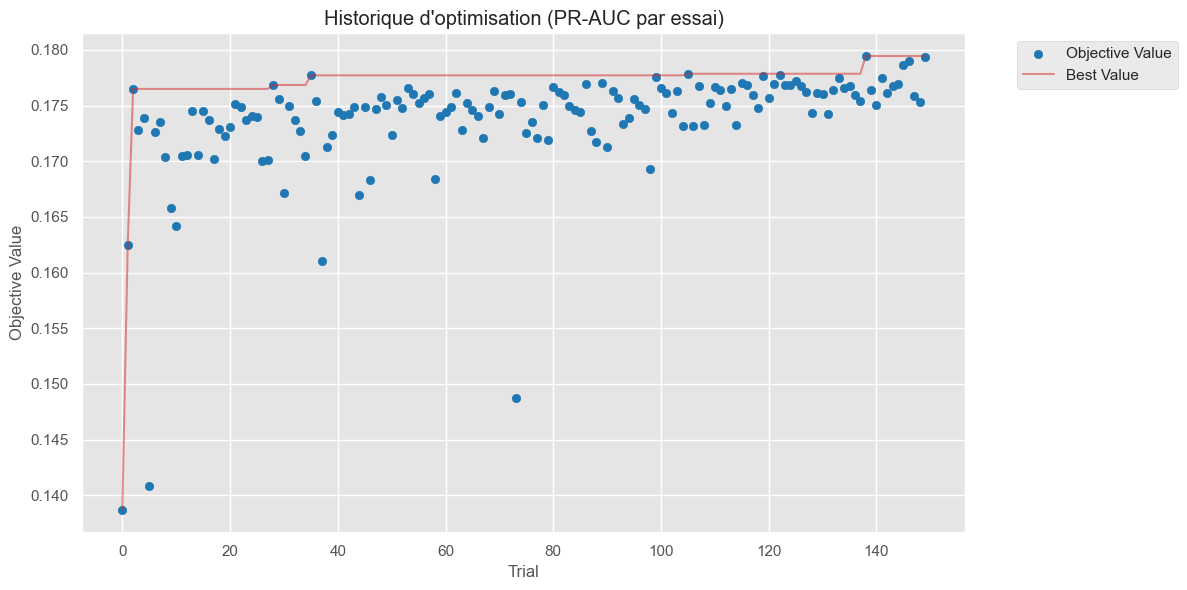

<Figure size 1100x600 with 0 Axes>

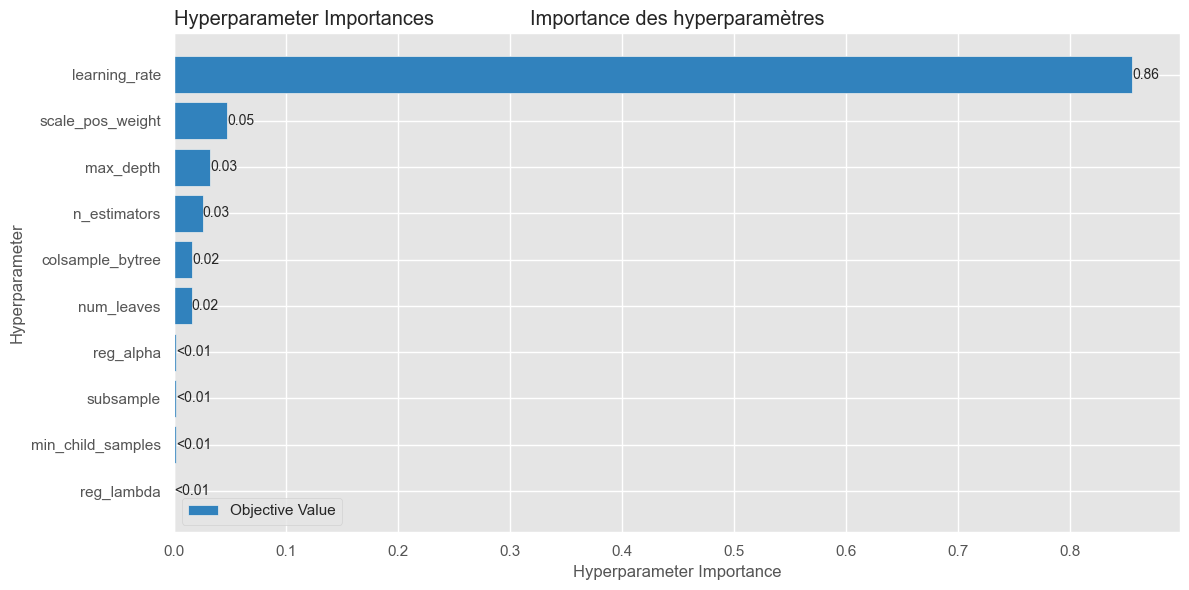

In [7]:
# =============================================================
# SECTION 5 (suite) — VISUALISATIONS OPTUNA
# =============================================================

# AMÉLIORATION 5 : graphiques natifs d'Optuna (via matplotlib)
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances,
)

# --- Historique de convergence ---
# Montre si 150 essais suffisent (la courbe se stabilise-t-elle ?)
fig = plt.figure(figsize=(11, 5))
ax = plot_optimization_history(study)
plt.title("Historique d'optimisation (PR-AUC par essai)")
plt.tight_layout()
plt.savefig(FIGURES / "optuna_history.png", dpi=120, bbox_inches="tight")
plt.show()

# --- Importance des hyperparamètres ---
# Quels hyperparamètres influencent le plus la performance ?
fig = plt.figure(figsize=(11, 6))
ax = plot_param_importances(study)
plt.title("Importance des hyperparamètres")
plt.tight_layout()
plt.savefig(FIGURES / "optuna_param_importance.png", dpi=120, bbox_inches="tight")
plt.show()

### 🔧 Lecture des hyperparamètres retenus

Optuna a convergé vers un modèle **volontairement conservateur**, plus prudent que
le baseline du NB04 :

- `learning_rate = 0.027` (bas, contre 0.05 au baseline) et `n_estimators = 500`
  → apprentissage lent et prudent.
- `min_child_samples = 43` (élevé) → exige beaucoup d'exemples par feuille, évite
  de créer des règles sur trop peu de données.
- `subsample = 0.92`, `colsample_bytree = 0.70` → n'utilise qu'une partie des
  données et des features par arbre (échantillonnage aléatoire = anti-overfitting).
- `reg_lambda = 0.57` → régularisation active.

**Interprétation :** sur ce problème à signal faible, le risque principal n'est pas
le sous-apprentissage mais le **surapprentissage** (mémoriser du bruit). Optuna a
donc choisi des réglages qui brident volontairement le modèle pour qu'il généralise
mieux, plutôt que de maximiser l'ajustement au train.

**Le `scale_pos_weight = 6.93` est le choix le plus notable.** Le ratio de
déséquilibre réel est ~10 ; Optuna a retenu ~6.9, soit une pondération **plus douce**.
Conséquence attendue : moins de recall, mais plus de precision et surtout des
probabilités mieux calibrées (cf. section suivante).

In [8]:
# =============================================================
# SECTION 6 — MODÈLE FINAL OPTIMISÉ + CONTRÔLE
# =============================================================

# Réentraînement sur TOUT le train avec les meilleurs hyperparamètres
best_params = study.best_params
lgbm_tuned = LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
lgbm_tuned.fit(X_train, y_train)

# Évaluation sur le VAL set (données jamais vues pendant l'optimisation)
y_proba_val = lgbm_tuned.predict_proba(X_val)[:, 1]
y_pred_val  = lgbm_tuned.predict(X_val)

pr_auc_val = average_precision_score(y_val, y_proba_val)
roc_auc_val = roc_auc_score(y_val, y_proba_val)

# AMÉLIORATION 2 : contrôle CV vs val (détection de sur-optimisation)
print("=" * 55)
print("CONTRÔLE ANTI-SUROPTIMISATION")
print("=" * 55)
print(f"  PR-AUC en CV (train)  : {study.best_value:.4f}")
print(f"  PR-AUC sur val        : {pr_auc_val:.4f}")
ecart = abs(study.best_value - pr_auc_val)
print(f"  Écart CV vs val       : {ecart:.4f}")
if ecart < 0.02:
    print("  ✓ Écart faible → pas de sur-optimisation notable.")
else:
    print("  ⚠️  Écart notable → l'optimisation a peut-être sur-ajusté à la CV.")

CONTRÔLE ANTI-SUROPTIMISATION
  PR-AUC en CV (train)  : 0.1795
  PR-AUC sur val        : 0.1840
  Écart CV vs val       : 0.0046
  ✓ Écart faible → pas de sur-optimisation notable.


### ✅ Contrôle de généralisation

L'écart entre la PR-AUC en **CV sur le train** (0.180) et sur le **val** (0.184)
est faible (0.005 < 0.02). Cela confirme que l'optimisation **généralise** et n'a
pas sur-ajusté à la validation croisée. Le score légèrement meilleur sur le val
que en CV est un bon signe de robustesse.

> Ce contrôle est essentiel : une optimisation peut « tricher » en trouvant des
> hyperparamètres qui excellent sur les folds de CV mais échouent sur des données
> nouvelles. Vérifier CV vs val protège contre ce piège.

In [9]:
# =============================================================
# SECTION 7 — COMPARAISON BASELINE vs OPTIMISÉ (sur val)
# =============================================================

# Métriques complètes du modèle optimisé sur le val
metriques_tuned = {
    "ROC-AUC":     roc_auc_val,
    "PR-AUC":      pr_auc_val,
    "Recall":      recall_score(y_val, y_pred_val),
    "Precision":   precision_score(y_val, y_pred_val),
    "F2-Score":    fbeta_score(y_val, y_pred_val, beta=2),
    "Brier Score": brier_score_loss(y_val, y_proba_val),
}

# Comparaison côte à côte
comparaison = pd.DataFrame({
    "LightGBM baseline (NB04)": baseline_scores.loc["LightGBM",
        ["ROC-AUC", "PR-AUC", "Recall", "Precision", "F2-Score", "Brier Score"]],
    "LightGBM optimisé (NB05)": pd.Series(metriques_tuned),
})
comparaison["Gain"] = (comparaison["LightGBM optimisé (NB05)"]
                       - comparaison["LightGBM baseline (NB04)"])

print("=" * 55)
print("BASELINE vs OPTIMISÉ (val set)")
print("=" * 55)
display(comparaison.round(4))

# Lecture honnête du gain
gain_pr = comparaison.loc["PR-AUC", "Gain"]
if gain_pr > 0.01:
    print(f"\n✓ L'optimisation améliore nettement la PR-AUC ({gain_pr:+.4f}).")
elif gain_pr > 0:
    print(f"\n≈ L'optimisation apporte un gain modeste ({gain_pr:+.4f}), "
          "cohérent avec un signal faible.")
else:
    print(f"\n⚠️  L'optimisation n'améliore pas la PR-AUC ({gain_pr:+.4f}). "
          "Le baseline était déjà bien réglé.")

BASELINE vs OPTIMISÉ (val set)


,LightGBM baseline (NB04),LightGBM optimisé (NB05),Gain
ROC-AUC,0.6449,0.6656,0.0208
PR-AUC,0.1766,0.1840,0.0074
Recall,0.4390,0.2927,-0.1463
Precision,0.1590,0.1986,0.0396
F2-Score,0.3247,0.2673,-0.0573
Brier Score,0.1825,0.1605,-0.0219



≈ L'optimisation apporte un gain modeste (+0.0074), cohérent avec un signal faible.


### 📊 Baseline vs optimisé : un compromis, pas une victoire nette

Comparés à armes égales **sur le val set**, les deux modèles révèlent un compromis :

**Ce que l'optimisation améliore :**
| Métrique | Baseline | Optimisé | Gain |
|---|---|---|---|
| PR-AUC | 0.177 | 0.184 | **+0.007** |
| ROC-AUC | 0.645 | 0.666 | **+0.021** |
| Precision | 0.159 | 0.199 | **+0.040** |
| Brier Score | 0.183 | 0.161 | **-0.022** (mieux) |

**Ce que l'optimisation dégrade :**
| Métrique | Baseline | Optimisé | Perte |
|---|---|---|---|
| Recall | 0.439 | 0.293 | **-0.146** |
| F2-Score | 0.325 | 0.267 | **-0.057** |

**Explication :** le `scale_pos_weight` plus doux (6.9 vs ~10) rend le modèle plus
prudent. Il n'annonce « à risque » que lorsqu'il est plus sûr → meilleure precision
et meilleure calibration (Brier ↓), mais il **rate plus de vrais cas** (recall ↓).

**Le recall bas au seuil 0.5 n'est PAS rédhibitoire.** Le recall dépend du **seuil**,
et 0.5 est arbitraire. La PR-AUC (meilleure pour l'optimisé) résume la performance
sur *tous* les seuils. Au NB06, l'optimisation du seuil permettra de remonter le
recall en partant d'une base mieux calibrée.

In [10]:
# =============================================================
# SECTION 8 — SAUVEGARDE
# =============================================================

# Modèle optimisé
joblib.dump(lgbm_tuned, MODELS / "lgbm_tuned.pkl")

# Hyperparamètres (JSON lisible)
with open(REPORTS / "best_hyperparameters.json", "w") as f:
    json.dump(best_params, f, indent=2)

# AMÉLIORATION 6 : étude Optuna complète (pour ré-analyse ultérieure)
joblib.dump(study, MODELS / "optuna_study.pkl")

# Tableau de comparaison
comparaison.to_csv(REPORTS / "baseline_vs_tuned.csv")

print("✓ Fichiers sauvegardés :")
print(f"  models/lgbm_tuned.pkl        (modèle optimisé)")
print(f"  models/optuna_study.pkl      (étude complète)")
print(f"  reports/best_hyperparameters.json")
print(f"  reports/baseline_vs_tuned.csv")
print("\n➡️  Prochaine étape : NB06 — Évaluation finale (test set), calibration, seuil, SHAP")

✓ Fichiers sauvegardés :
  models/lgbm_tuned.pkl        (modèle optimisé)
  models/optuna_study.pkl      (étude complète)
  reports/best_hyperparameters.json
  reports/baseline_vs_tuned.csv

➡️  Prochaine étape : NB06 — Évaluation finale (test set), calibration, seuil, SHAP


## 🏁 Conclusion du NB06 — Optimisation

### Démarche
Optimisation de LightGBM par **Optuna** (TPE bayésien) : 150 essais, CV 5-fold
stratifiée, métrique PR-AUC, `scale_pos_weight` optimisé, reproductible (seed),
avec contrôle anti-suroptimisation.

### Résultat : un modèle mieux calibré, pas plus « performant » en brut
Le tuning **n'augmente pas spectaculairement** la performance — attendu sur un
problème à signal faible où la limite vient des **données**, pas du réglage. Mais
il produit un modèle **qualitativement différent** :
- Meilleure PR-AUC (+0.007) et ROC-AUC (+0.021)
- Nettement meilleure calibration (Brier -0.022) → probabilités plus fiables
- Meilleure precision, au prix d'un recall plus bas au seuil 0.5

### Décision : garder le modèle optimisé
On retient **`lgbm_tuned.pkl`** pour le NB06, car :
1. Meilleure PR-AUC (métrique de décision) et meilleure calibration.
2. Des probabilités fiables sont cruciales pour le dashboard Streamlit
   (on montre un score à un praticien).
3. Le recall se rattrapera par l'**optimisation du seuil** au NB06.

### Enseignement
Le tuning ne se juge pas au seul gain de performance brute : ici, sa vraie valeur
est la **calibration**. Reconnaître qu'on a atteint la limite intrinsèque du signal
(et non un échec de méthode) fait partie de la démarche scientifique.

### Prochaine étape
**NB06** — Évaluation finale sur le **test set** (jamais touché), calibration,
optimisation du seuil de décision (priorité médicale : recall), et explicabilité SHAP.